# 03 — Déviation de la lumière (lentille gravitationnelle)

**Le test de 1919 qui a rendu Einstein célèbre dans le monde entier.**

Newton avait déjà imaginé (avec sa théorie corpusculaire de la lumière) que la lumière pouvait être déviée par la gravité. Sa prédiction pour un rayon rasant le Soleil : $\alpha_{\rm Newton} = 2GM/(bc^2) \approx 0.875''$.

**Einstein prédit le double** : $\alpha_{\rm GR} = 4GM/(bc^2) \approx 1.75''$.

En mai 1919, l'expédition d'Eddington photographie les étoiles autour du Soleil pendant une éclipse totale et mesure environ 1.75''. La GR gagne — Einstein devient une célébrité mondiale du jour au lendemain.

## Théorie

Pour les **photons** (géodésiques nulles), l'équation de Binet devient :
$$\frac{d^2 u}{d\varphi^2} + u = \frac{3GM}{c^2}\,u^2 \quad (u = 1/r)$$

Le terme newtonien $GM/h^2$ disparaît (un photon n'a pas de masse) — la déviation **est** purement relativiste.

En faible champ ($b \gg r_s$), un développement perturbatif donne $\alpha \approx 4GM/(bc^2)$.
En champ fort, des corrections d'ordre supérieur apparaissent — et au-delà d'un seuil critique, le photon est carrément **capturé** par le trou noir.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

from src.config import G, C, M_SUN, R_SUN
from src.relativity import (
    simulate_photon_schwarzschild,
    measure_deflection_angle,
    light_deflection_angle,
    schwarzschild_radius,
)

plt.rcParams['figure.dpi'] = 110

ARCSEC_PER_RAD = (180.0 / np.pi) * 3600.0

## 1. Reproduire le test de 1919

Un photon vient de l'infini, rase la surface du Soleil ($b = R_\odot$), et repart vers l'infini. On mesure l'angle entre la direction d'arrivée et la direction de départ.

In [3]:
b = R_SUN
alpha_sim     = measure_deflection_angle(M_SUN, b)
alpha_gr_th   = light_deflection_angle(M_SUN, b)
alpha_newton  = alpha_gr_th / 2.0

print(f"Paramètre d'impact b = R_sun = {b:.3e} m")
print(f"Rayon Schwarzschild  rs    = {schwarzschild_radius(M_SUN):.2f} m")
print(f"b / rs               = {b/schwarzschild_radius(M_SUN):.2e}  (régime très faible)\n")
print(f"Newton (corpusculaire) : α = {alpha_newton*ARCSEC_PER_RAD:.4f} arcsec")
print(f"GR théorique 4GM/bc²   : α = {alpha_gr_th*ARCSEC_PER_RAD:.4f} arcsec")
print(f"GR simulation          : α = {alpha_sim*ARCSEC_PER_RAD:.4f} arcsec")
print(f"\nMesuré en 1919 (Eddington) : 1.61'' ± 0.30''  (compatible avec GR, exclut Newton)")

Paramètre d'impact b = R_sun = 6.957e+08 m
Rayon Schwarzschild  rs    = 2954.01 m
b / rs               = 2.36e+05  (régime très faible)

Newton (corpusculaire) : α = 0.8758 arcsec
GR théorique 4GM/bc²   : α = 1.7516 arcsec
GR simulation          : α = 1.7517 arcsec

Mesuré en 1919 (Eddington) : 1.61'' ± 0.30''  (compatible avec GR, exclut Newton)


## 2. Visualisation de la trajectoire

À l'échelle du Soleil, la déviation est invisible à l'œil (1.75 arcsec sur une trajectoire de plusieurs UA). On va donc visualiser un cas **amplifié** : un photon passant près d'un objet compact (b proche de $r_s$).

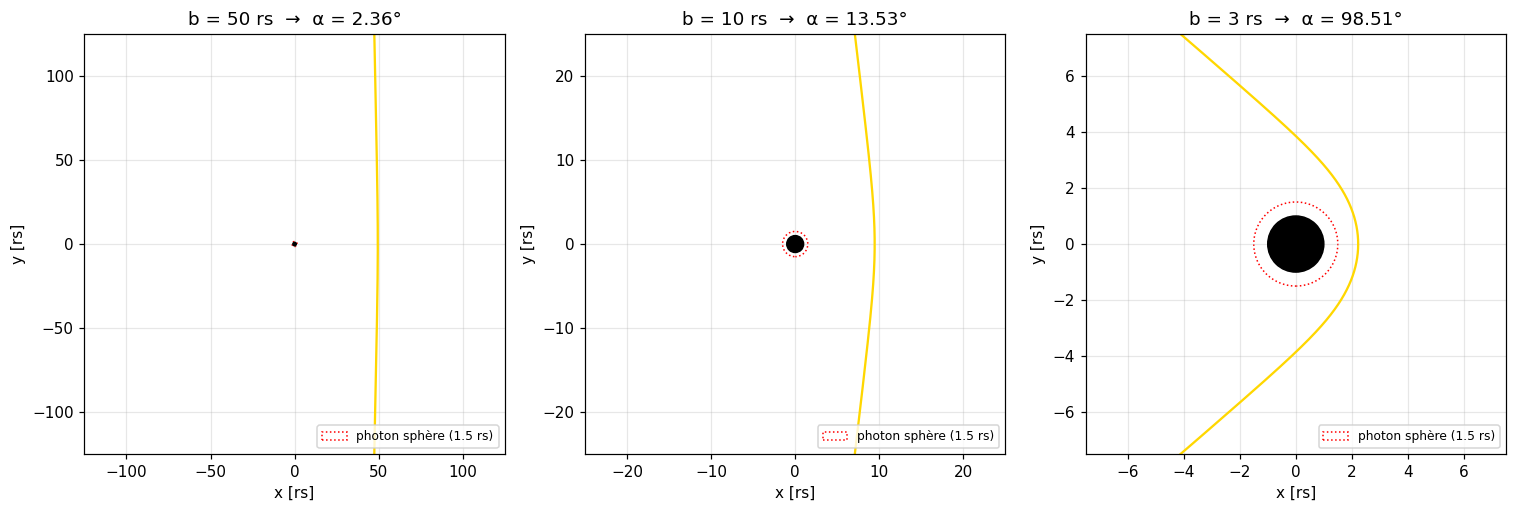

In [4]:
# Objet compact (10 M_sun)
M = 10 * M_SUN
rs = schwarzschild_radius(M)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, b_in_rs in zip(axes, [50, 10, 3]):
    b = b_in_rs * rs
    res = simulate_photon_schwarzschild(M, b, phi_max=10*np.pi, n_points=10000)
    alpha = measure_deflection_angle(M, b, phi_max=10*np.pi)

    ax.plot(res.x/rs, res.y/rs, color='gold', lw=1.5)
    ax.add_patch(plt.Circle((0,0), 1, color='black', zorder=5))           # horizon
    ax.add_patch(plt.Circle((0,0), 1.5, color='red', fill=False, ls=':',  # photon sphere
                            lw=1, label='photon sphère (1.5 rs)'))
    ax.set_aspect('equal')
    L = max(b_in_rs * 2.5, 5)
    ax.set_xlim(-L, L); ax.set_ylim(-L, L)
    ax.set_xlabel('x [rs]'); ax.set_ylabel('y [rs]')
    ax.set_title(f'b = {b_in_rs} rs  →  α = {np.degrees(alpha):.2f}°')
    ax.grid(alpha=0.3); ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 3. Newton vs GR vs simulation — diagramme

On compare les trois prédictions sur une large plage de paramètres d'impact, et on identifie où la formule faible champ devient insuffisante.

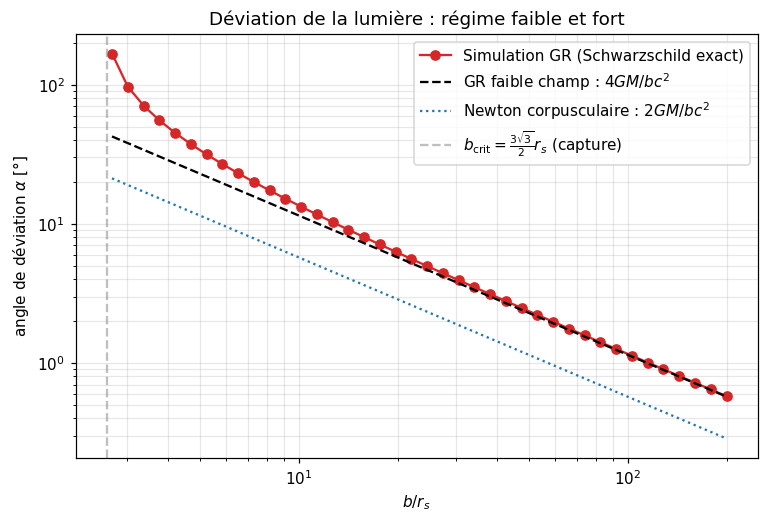

In [5]:
M = 10 * M_SUN
rs = schwarzschild_radius(M)

b_over_rs = np.geomspace(2.7, 200, 40)
alpha_sim_deg = []
alpha_th_deg = []

for x in b_over_rs:
    b = x * rs
    try:
        a_sim = measure_deflection_angle(M, b, phi_max=20*np.pi)
    except (ValueError, RuntimeError):
        a_sim = np.nan       # photon capturé (b ≤ b_crit) ou intégration incomplète
    alpha_sim_deg.append(np.degrees(a_sim))
    alpha_th_deg.append(np.degrees(light_deflection_angle(M, b)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(b_over_rs, alpha_sim_deg, 'o-', color='#d62728', label='Simulation GR (Schwarzschild exact)')
ax.plot(b_over_rs, alpha_th_deg,  '--', color='black',  label=r'GR faible champ : $4GM/bc^2$')
ax.plot(b_over_rs, np.array(alpha_th_deg)/2, ':', color='#1f77b4', label=r'Newton corpusculaire : $2GM/bc^2$')
ax.axvline(1.5*np.sqrt(3), color='gray', ls='--', alpha=0.5, label=r'$b_{\rm crit} = \frac{3\sqrt{3}}{2} r_s$ (capture)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$b / r_s$'); ax.set_ylabel(r'angle de déviation $\alpha$ [°]')
ax.set_title('Déviation de la lumière : régime faible et fort')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.show()

**Lectures du graphe** :
- À $b \gtrsim 30\,r_s$ : Newton et GR théorique sont à un facteur 2, simulation = GR théorique.
- À $b \lesssim 10\,r_s$ : la simulation **dépasse** la formule faible champ — les termes d'ordre supérieur en $GM/(bc^2)$ deviennent significatifs.
- À $b \to b_{\rm crit} = \frac{3\sqrt{3}}{2} r_s \approx 2.6\,r_s$ : la déviation **diverge logarithmiquement** ; le photon fait un nombre arbitraire de tours autour du trou noir avant de s'échapper (c'est l'orbite limite de la **photon sphère**).
- À $b < b_{\rm crit}$ : capture pure — le photon plonge sous l'horizon.

## 4. Explorateur interactif

In [6]:
M = 10 * M_SUN
rs = schwarzschild_radius(M)

def explore_deflection(b_over_rs=5.0):
    b = b_over_rs * rs
    fig, ax = plt.subplots(figsize=(8, 8))
    try:
        res = simulate_photon_schwarzschild(M, b, phi_max=20*np.pi, n_points=20000)
        alpha = measure_deflection_angle(M, b, phi_max=20*np.pi)
        ax.plot(res.x/rs, res.y/rs, color='gold', lw=1.5)
        title = f'b = {b_over_rs:.2f} rs   →   α = {np.degrees(alpha):.2f}°'
    except (ValueError, RuntimeError):
        title = f'b = {b_over_rs:.2f} rs ≤ b_crit   →   CAPTURE (photon plonge sous l\'horizon)'

    ax.add_patch(plt.Circle((0,0), 1, color='black', zorder=5))
    ax.add_patch(plt.Circle((0,0), 1.5, color='red', fill=False, ls=':', lw=1))
    ax.set_aspect('equal')
    L = max(b_over_rs * 2, 4)
    ax.set_xlim(-L, L); ax.set_ylim(-L, L)
    ax.set_xlabel('x [rs]'); ax.set_ylabel('y [rs]')
    ax.set_title(title); ax.grid(alpha=0.3)
    plt.show()

interact(
    explore_deflection,
    b_over_rs=FloatSlider(value=5.0, min=2.55, max=30.0, step=0.05,
                          description='b [rs]', readout_format='.2f'),
);

interactive(children=(FloatSlider(value=5.0, description='b [rs]', max=30.0, min=2.55, step=0.05), Output()), …

## Bilan

| Régime | Newton corpusculaire | GR faible champ | GR exact |
|---|---|---|---|
| Photon rasant le Soleil ($b = R_\odot$) | 0.875'' | **1.75''** | 1.75'' |
| Photon à 10 rs d'un BH | --- | 11.5° | 12.7° |
| Photon à 3 rs d'un BH | --- | 38° | 58° |
| Photon à $b_{\rm crit}$ | --- | borné | **∞ (orbite limite)** |

La déviation de la lumière par la gravité est **purement relativiste** : le facteur 2 entre Newton et GR vient de la courbure de l'espace en plus de celle du temps. Newton ne peut prédire correctement que dans la limite très faible champ, et seulement avec une théorie corpusculaire bancale. La GR, elle, prédit aussi le comportement en champ fort (capture, photon sphère, anneau d'Einstein).

**Suite** : notebook 04 — système solaire complet en N-corps newtonien.